# Impact of $A$ on dipole + $m_5$g map

The goal of this notebook is to study the impact of A on the injected dipole measurement when the $m_5$ is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## $m_5$ magnitude

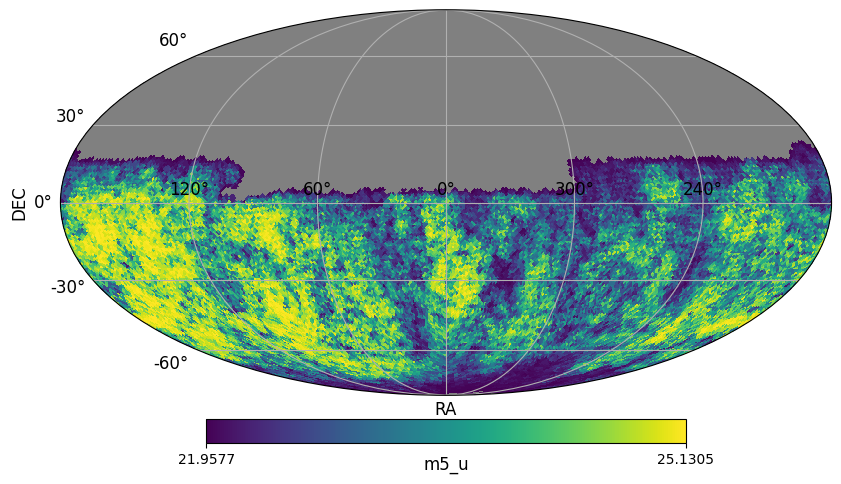

In [3]:
DIR_m5 = '../data/'
FILE = DIR_m5 + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'u'
dm.select_band(band)
dm.set_mask()
dm.plot()

## Reference spectrum

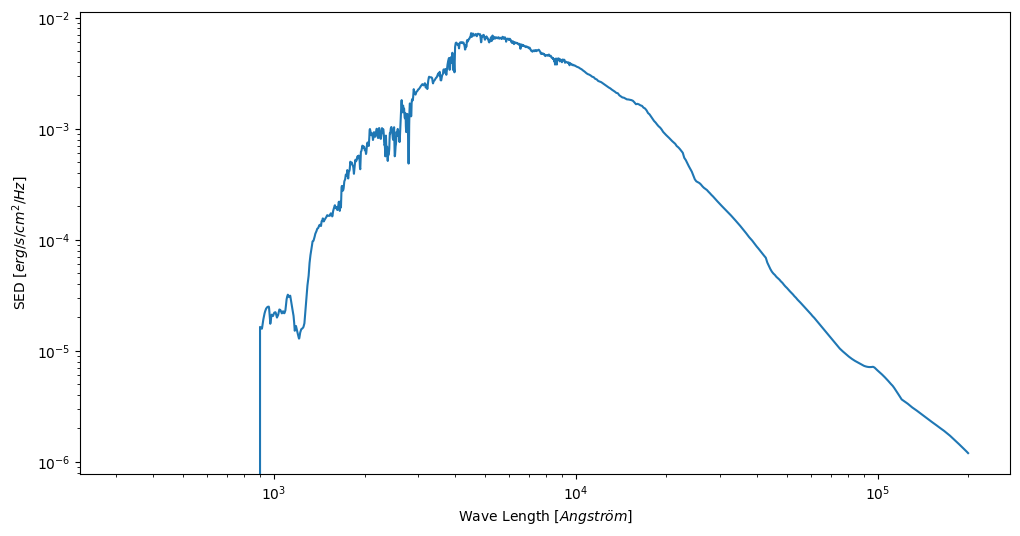

In [4]:
DIR_SED = "../data/data SED/SED GAL/COSMOS/"
FILE_SED = "Ell1_A_0"
file = DIR_SED + FILE_SED + ".sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True, title="");

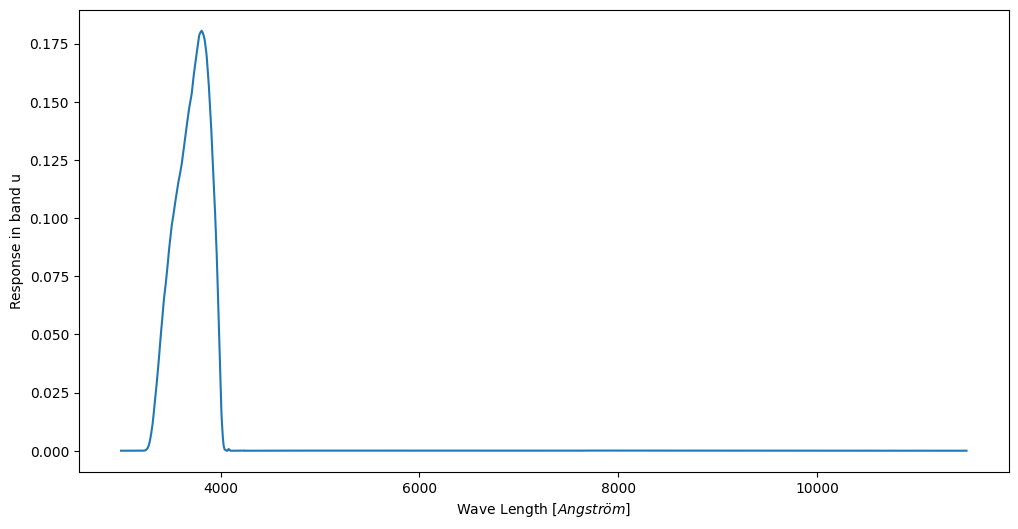

In [5]:
file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="");

In [6]:
_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

SED band u ratio : 0.013291492416839587


## Importing $N_{th}$ map

In [7]:
DIR_Nth = "Catalog_m5/Catalog_m5Nth/"
sufix = "NthPoisson"
file_Nth = DIR_Nth + sufix + '.fits'

data_Nth = fitsio.FITS(file_Nth)
data_Nth


  file: Catalog_m5/Catalog_m5Nth/NthPoisson.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      Nth_1e6

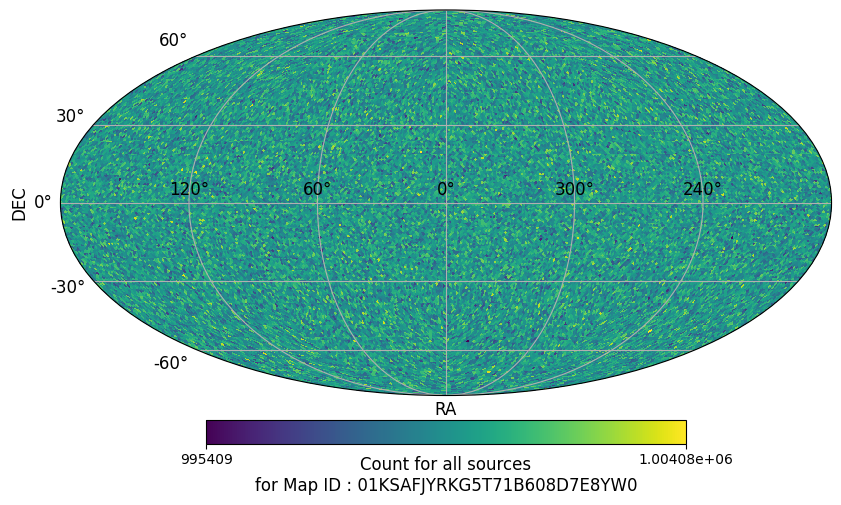

In [8]:
mapID_Nth, hpmap = data_Nth['Nth_1e6'][0] #first Nth map
count_thMapper = CountMapper.from_map(hpmap)
count_thMapper._set_suffixTextPlot(unit = f"all sources\nfor Map ID : {mapID_Nth}")
count_thMapper.plot()

## Importing bolometric data file

In [9]:
DIR_cat = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
file_cat = DIR_cat + sufix + '.fits'

dataN, data_ID = read_lumMag_fits(file_cat, 0, L_bandRatio=L_bandRatio, to_band=band)
dataN

z,dL,L,M,m,L_u,M_u,m_u
,Mpc,solLum,,,solLum,solLum,solLum
float64,float64,float64,float64,float64,float64,float64,float64
1.014542326432987,7027.145682378759,30645546.713645894,-13.885918433823983,30.34797635193339,407325.0517543277,-9.19485280341342,35.03904198234395
0.7363209110631574,4734.488512540824,2677336894.761015,-18.73925755696431,24.63710777876085,35585803.034040876,-14.04819192655375,29.328173409171413
0.8083768640688359,5309.647095345624,25510623.16818487,-13.686802668986099,29.938525614728903,339074.2543887815,-8.99573703857554,34.62959124513946
0.45044390448429966,2612.4876463369646,15778842.982701296,-13.165187886180528,28.920083341203785,209724.3718510768,-8.474122255769968,33.61114897161435
0.4987659532367315,2950.87540205728,12663883.576797798,-12.926417273155431,29.423337087896755,168321.9125287473,-8.235351642744869,34.11440271830732
0.8516695348807279,5661.8510749809375,125990258.58744024,-15.42084241824489,28.34394979089506,1674598.5666106206,-10.72977678783433,33.035015421305616
0.8438439425794242,5597.832695085243,794616713.3066007,-17.42039423851022,26.319705333348903,10561642.019208679,-12.729328608099655,31.01077096375947
0.32696617180733534,1792.138316712811,169180714.42846972,-15.740877136493586,25.5259804902122,2248664.182901509,-11.049811506083023,30.21704612062276


## Ratio and detected map creation

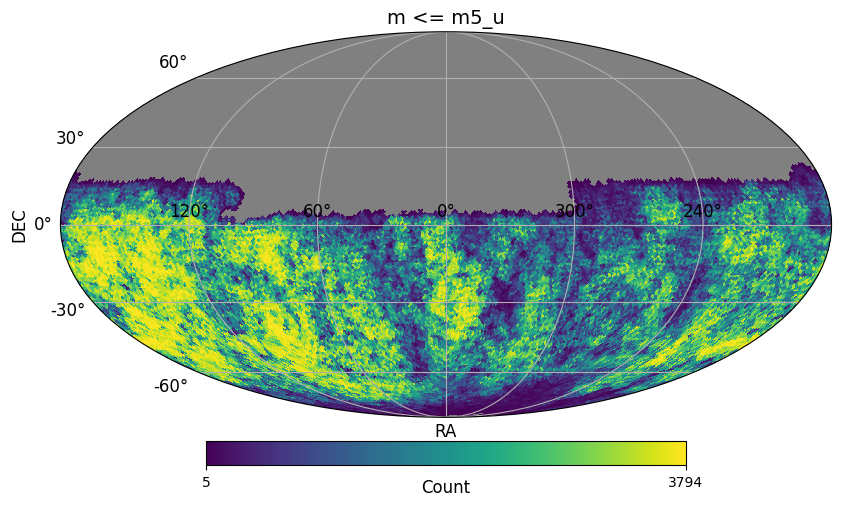

In [10]:
_, hpmap_band = dm._get_band_map(band)
NSource_px = cut_m52map(dataN[f"m_{band}"], hpmap_band)
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= f"m <= m5_{band}")

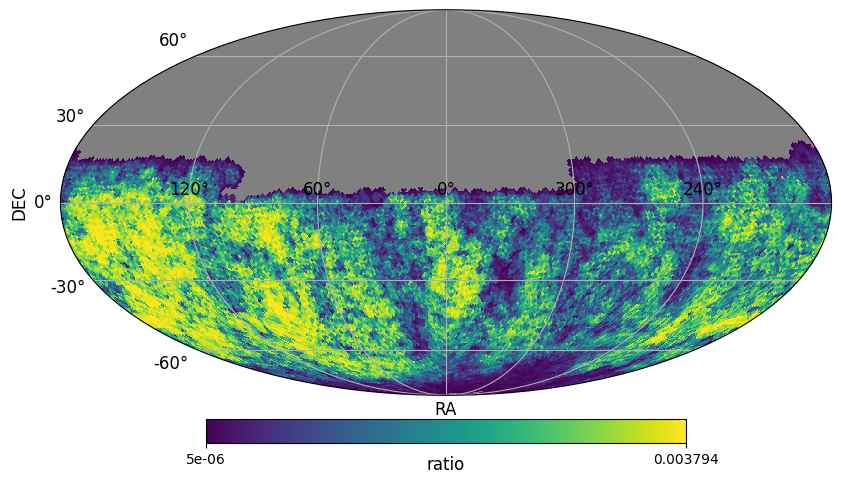

In [11]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked", norm="hist")

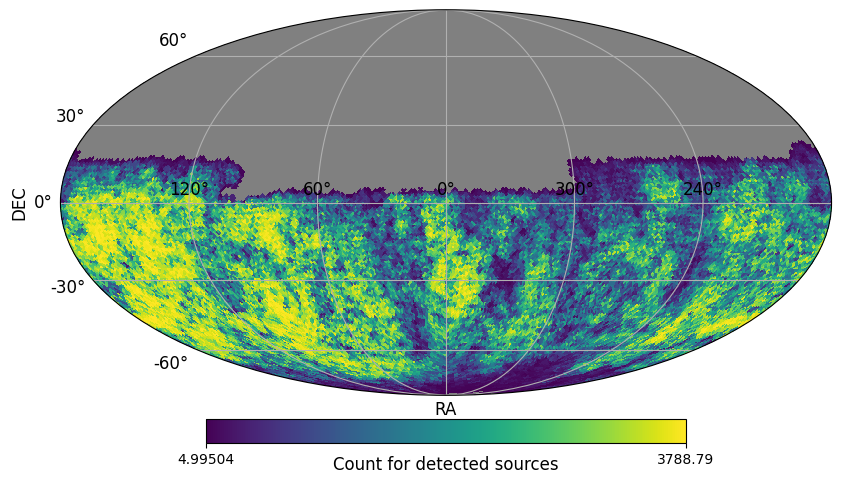

In [12]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

## Importing clustering

In [13]:
DIR_cl = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR_cl + sufix + '.fits'

data_cl = fitsio.FITS(clFile)
data_cl


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_zmin0.1.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY

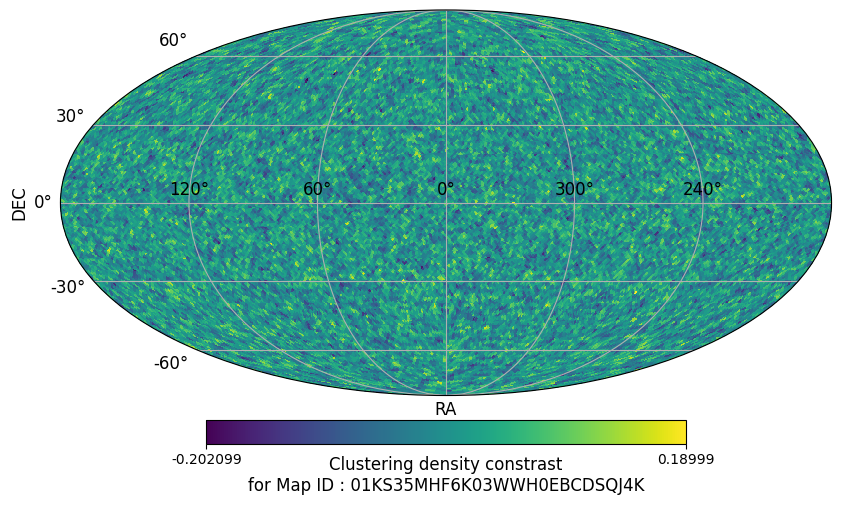

In [14]:
mapID_cl, hpmap = data_cl['MAPS'][0] #first clustering map
hpmap = hp.reorder(hpmap, r2n=True)
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID_cl}")
clMapper.plot()

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.456e-07 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 3.46e-07 (Goal: 0.0002)    │            time = 4.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ ra   │  168.00   │   0.23    │   -0.23    │    0.23    │    0    │   360   │       │
│ 2 │ dec  │   -7.0    │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │   -0.23   │   0.23    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6     0e-6 │
│  ra │    -0e-6   0.0509    -0.03 │
│ dec │     0e-6    -0.03    0.134 │
└─────┴────────────────────────────┘

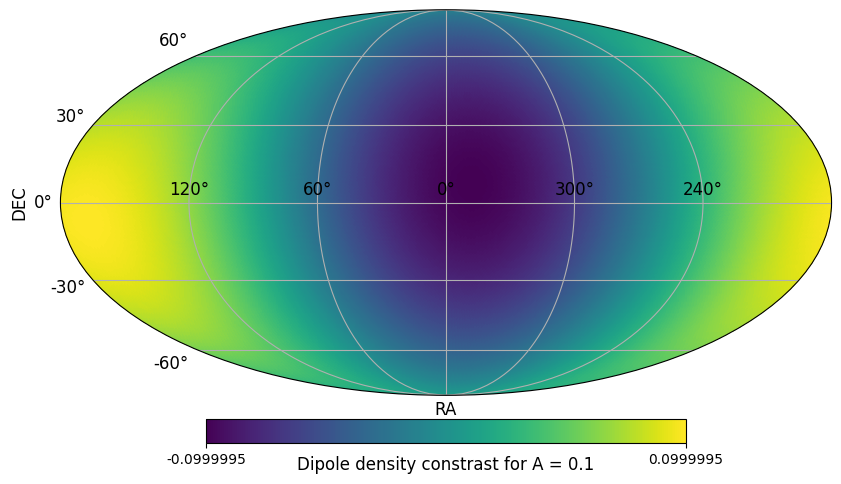

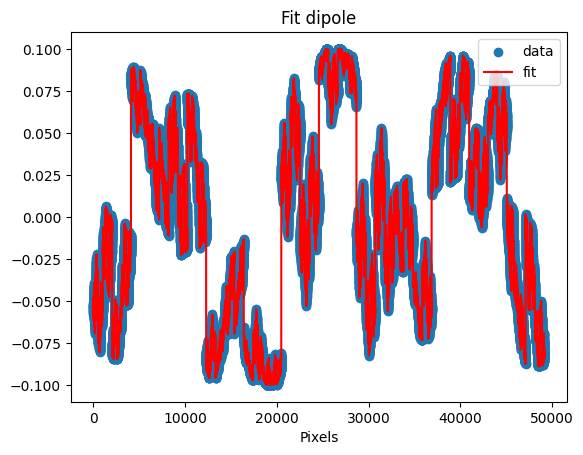

In [15]:
nest = True
A, l, b = 0.1, 168, -7
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Applying dipole

### Study of $A$

In [21]:
def get_m5DipMonop(A, l=l, b=b, M=NSource_px_th, add_cl=False):
    dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
    dipoleMapper = CountMapper.from_map(dipole, nest=nest)
    dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

    dipoleClMapper = dipoleMapper.add(clMapper)
    dipoleClMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}\nwith clustering ID : {mapID_cl}")

    if add_cl: monop = apply_monopole_Mcontrast(dipoleClMapper.map, countDetectedMapper.map)
    else: monop = apply_monopole_Mcontrast(dipoleMapper.map, countDetectedMapper.map)
    countObservedMapper = CountMapper.from_map(monop)
    countObservedMapper._set_suffixTextPlot(unit = f"observed sources\ndipole A = {A}, and monopole N* = {NSource_px_th}")
    hpmapMasked = dm._select_useMap(f'{band}Masked')
    countObservedMapper.set_mask(hpmapMasked.mask)

    countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
    countCorrectedMapper.fillna()
    countCorrectedMapper._set_suffixTextPlot(unit = f"corrected sources\ndipole A = {A}, and monopole N* = {NSource_px_th}")
    countCorrectedMapper.set_mask()

    return countCorrectedMapper, dipoleClMapper, dipoleMapper


def get_add_param(m, A, l=l, b=b, M=NSource_px_th, add_cl=False):
    add_param = {"Nth_ID": mapID_Nth, "Ratio_ID": data_ID, "BAND": band}
    if add_cl: add_param["Cluster_ID" ] = mapID_cl
    for k, v in zip(m.values.to_dict().keys(), (M, A, l, b)): add_param[k + "_true"] = v
    return add_param


def get_compute(A, l=l, b=b, M=NSource_px_th, init=(1e6, 1, 100, 0), fixed=[], add_cl=False):
    monopMapper, dipoleClMapper, dipoleMapper = get_m5DipMonop(A, l, b, M, add_cl)
    m = monopMapper.fit_dipole("Masked", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    add_param = get_add_param(m, A, l, b, M, add_cl)
    dic_param = get_dicParam_minuit(m, "NaN", add_param=add_param)
    return m, dic_param, monopMapper



add_cl = True
Alist = np.logspace(-3, -1, 50)
Atest = Alist[0]

M, init = NSource_px_th, (NSource_px_th, 1, 100, 0)
fixed = ['N*']
fixed = []
m, dic_param, monopMapper = get_compute(Atest, M=M, init=init, fixed=fixed, add_cl=add_cl)
dfMinuit = dic_param.copy()
m

/tmp/ipykernel_9228/3296240186.py:16: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.704e+07 (χ²/ndof = 1364.0)│              Nfcn = 623              │
│ EDM = 0.000179 (Goal: 0.0002)    │           time = 10.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.988e3 │  0.009e3  │  -0.009e3  │  0.009e3   │    0    │         │       │
│ 1 │ A    │ 1.813e-3  │ 0.010e-3  │ -0.010e-3  │  0.011e-3  │    0    │    1    │       │
│ 2 │ ra   │  190.50   │   0.34    │   -0.34    │    0.33    │    0    │   360   │       │
│ 3 │ dec  │   23.9    │    0.5    │    -0.5    │    0.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -9     │     9     │ -0.010e-3 │ 0.011e-3  │   -0.34   │   0.33    │   -0.5    │    0.5    │
│  Valid   │   True    │   True    │   True    │   True    │   False   │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │          78 30.11726e-6       -0.10        3.38 │
│   A │ 30.11726e-6    1.08e-10   -29.10e-9  1.52128e-6 │
│  ra │       -0.10   -29.10e-9       0.112       -0.01 │
│ dec │        3.38  1.52128e-6       -0.01       0.265 │
└─────┴─────────────────────────────────────────────────┘

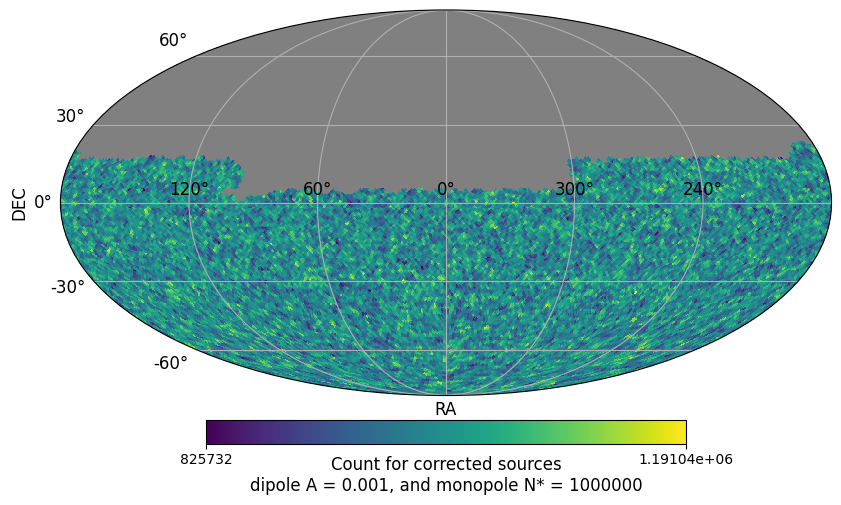

In [22]:
monopMapper.plot('Masked')

In [23]:
for i in range(len(Alist[1:])):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    Atest = Alist[1:][i]
    m, dic_param, monopMapper = get_compute(Atest, M=M, init=init, fixed=fixed, add_cl=add_cl)
    dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)

print('\nFit complete')

i = 0	

/tmp/ipykernel_9228/3296240186.py:16: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


i = 10	i = 20	i = 30	i = 40	
Fit complete


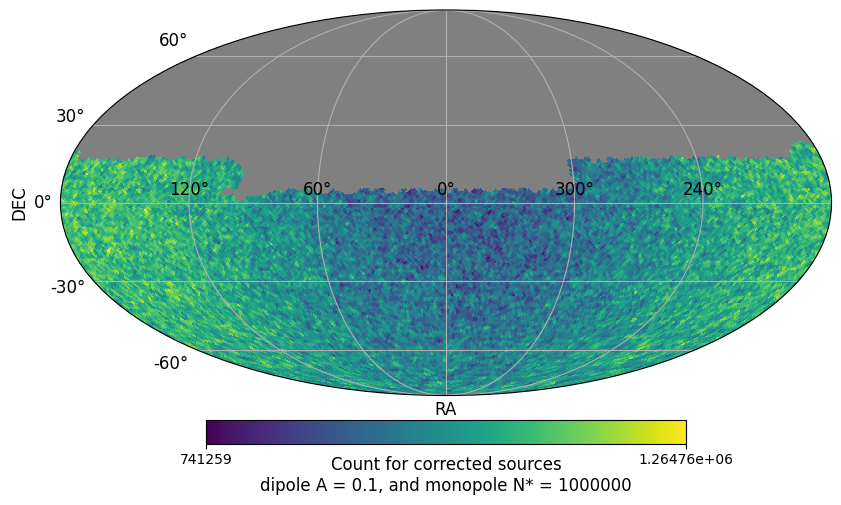

In [24]:
monopMapper.plot('Masked')

#### Saving data

In [25]:
output_path = "Fit_m5/m5_Dipole/m5_Dipole_"
if add_cl: sufix = "Param_study_Cluster"
else: sufix = "Param_study_NoCluster"
outputfile = output_path + sufix +".fits"

# header_global = {'MAP_TYPE': 'm5_Observed', 'INJECT_DIPOLE': True, 'INJECT_CLUSTERING': add_cl}
# create_primaryHDU(outputfile, header_global)

dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target='A_STUDY')

Saving Dataframe results in Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster.fits
Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:245: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)


## Study without clustering

In [26]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_NoCluster"
outputfile = DIR + sufix +".fits"

data2 = fitsio.FITS(outputfile)
data2


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_NoCluster.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [27]:
dfMinuit_data2 = Table(data2['A_STUDY'].read())
mask = dfMinuit_data2["BAND"] == band
dfMinuit_filtered = dfMinuit_data2[mask]
#dfMinuit_filtered = dfMinuit.copy()
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true
str3,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64
NaN,1000001.17640465,1000000.0,8.84422117844224,False,0.0,inf,0.0009792510871929937,1.0,1.013966125444426e-05,False,0.0,1.0,168.6171078711164,100.0,0.5737398941851808,False,0.0,360.0,-5.491686082480399,0.0,0.96086761179374,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7
NaN,1000001.166574354,1000000.0,8.845474200090393,False,0.0,inf,0.0010777559834522364,1.0,1.0149335318304252e-05,False,0.0,1.0,168.56084039782047,100.0,0.5214329836843206,False,0.0,360.0,-5.6304180009630596,0.0,0.8728909114319934,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7
NaN,1000001.1630836813,1000000.0,8.844077962450683,False,0.0,inf,0.0011859676797606503,1.0,1.015714257748292e-05,False,0.0,1.0,168.50990914820957,100.0,0.4739747904357756,False,0.0,360.0,-5.755514335748471,0.0,0.7928617990075884,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7
NaN,1000001.1645899457,1000000.0,8.845225467928685,False,0.0,inf,0.0013048591758811259,1.0,1.016529552817834e-05,False,0.0,1.0,168.4634066942663,100.0,0.4308834775619488,False,0.0,360.0,-5.868516910678828,0.0,0.72052749593538,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7
NaN,1000001.1653929364,1000000.0,8.845108349923976,False,0.0,inf,0.001435467070166241,1.0,1.017232271793237e-05,False,0.0,1.0,168.420999805192,100.0,0.39176141398303344,False,0.0,360.0,-5.971510042864155,0.0,0.6547942093210768,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7
NaN,1000001.1678826268,1000000.0,8.844119698391296,False,0.0,inf,0.0015789654583955237,1.0,1.0178364472279515e-05,False,0.0,1.0,168.38296424769473,100.0,0.3562309962476178,False,0.0,360.0,-6.065032108681973,0.0,0.5950779196504294,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0015998587196060573,168,-7
NaN,1000001.1623827181,1000000.0,8.84491822682321,False,0.0,inf,0.0017365818796905728,1.0,1.0184770006862521e-05,False,0.0,1.0,168.3483846406093,100.0,0.323953339609389,False,0.0,360.0,-6.150029102060622,0.0,0.5410067537688672,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0017575106248547913,168,-7
NaN,1000001.1683721263,1000000.0,8.844101872527972,False,0.0,inf,0.0019097474976093767,1.0,1.0189950747351798e-05,False,0.0,1.0,168.3168556422441,100.0,0.29462962280547345,False,0.0,360.0,-6.226356610300608,0.0,0.4918092702027006,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0019306977288832496,168,-7
NaN,1000001.162651138,1000000.0,8.844081679242663,False,0.0,inf,0.002099998174347842,1.0,1.0195049012868369e-05,False,0.0,1.0,168.28905676692213,100.0,0.2679794715128452,False,0.0,360.0,-6.2974044491783046,0.0,0.44717727256359785,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0021209508879201904,168,-7


#### Plotting graphs

Saving m5_A_study_val_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_val_NoCluster_band_u.pdf


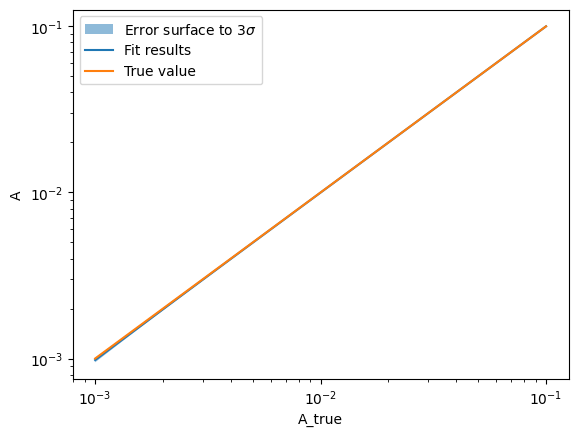

In [28]:
compareFit_val(dfMinuit_filtered, "A", "A", yscale='log', nsigma=3)
clSuffix_NoClust = f"NoCluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_NoClust = f"{output_path}Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_{clSuffix_NoClust}/"
sufix = f"m5_A_study_val_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_err_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_err_NoCluster_band_u.pdf


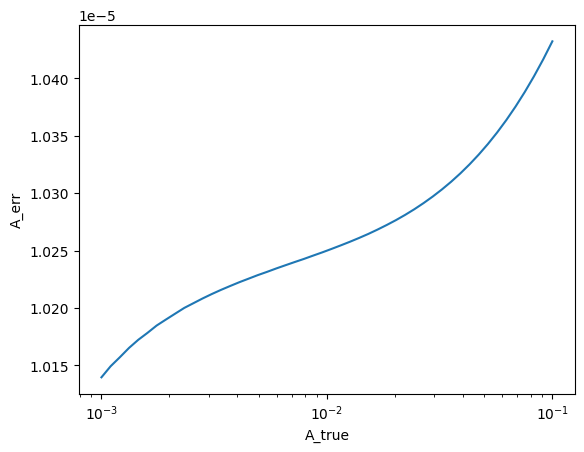

In [29]:
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_err"], label="Fit error")
plt.xlabel('A_true')
plt.ylabel('A_err')
plt.xscale('log');

sufix = f"m5_A_study_err_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diff_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diff_NoCluster_band_u.pdf


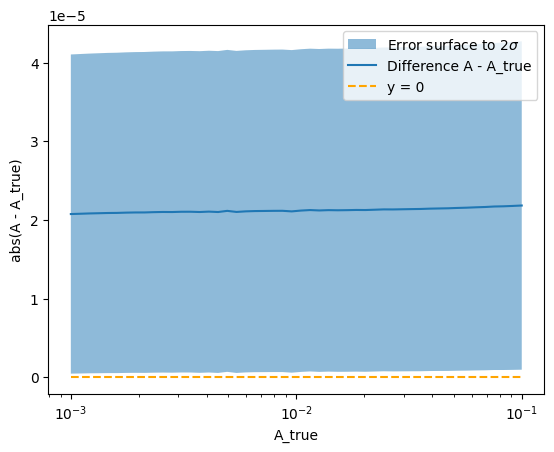

In [30]:
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2)
sufix = f"m5_A_study_diff_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_valRA_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_valRA_NoCluster_band_u.pdf


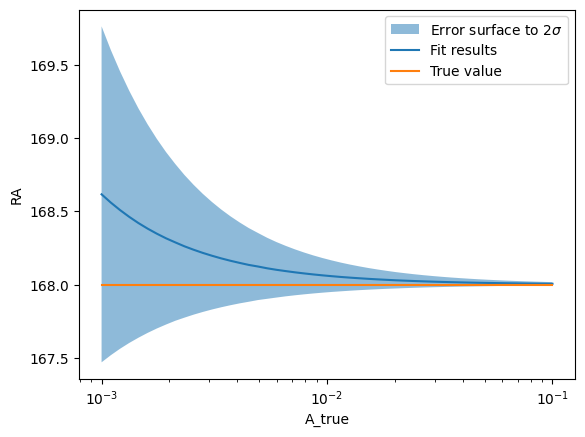

In [31]:
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=2)

sufix = f"m5_A_study_valRA_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffRA_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffRA_NoCluster_band_u.pdf


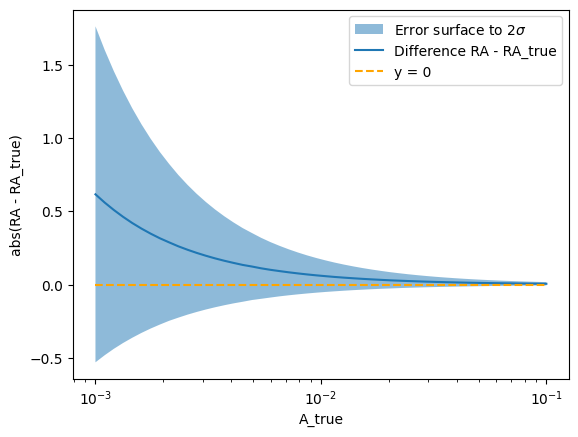

In [32]:
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2)

sufix = f"m5_A_study_diffRA_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_valDEC_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_valDEC_NoCluster_band_u.pdf


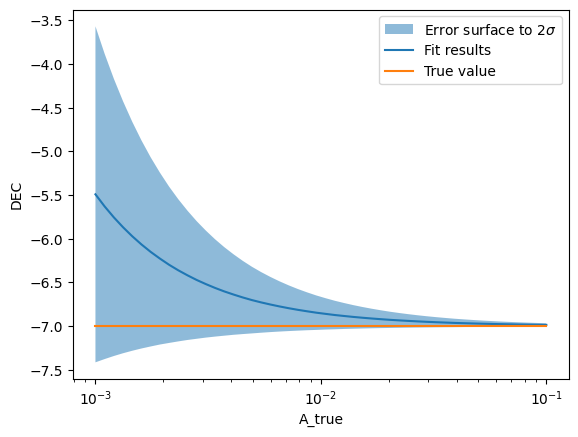

In [33]:
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=2)

sufix = f"m5_A_study_valDEC_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffDEC_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffDEC_NoCluster_band_u.pdf


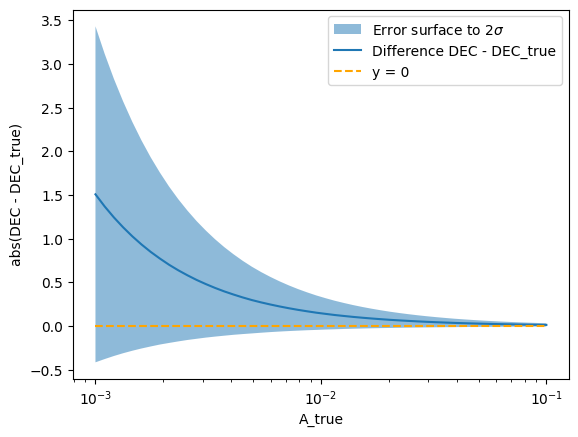

In [34]:
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2)

sufix = f"m5_A_study_diffDEC_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffARaDec_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffARaDec_NoCluster_band_u.pdf


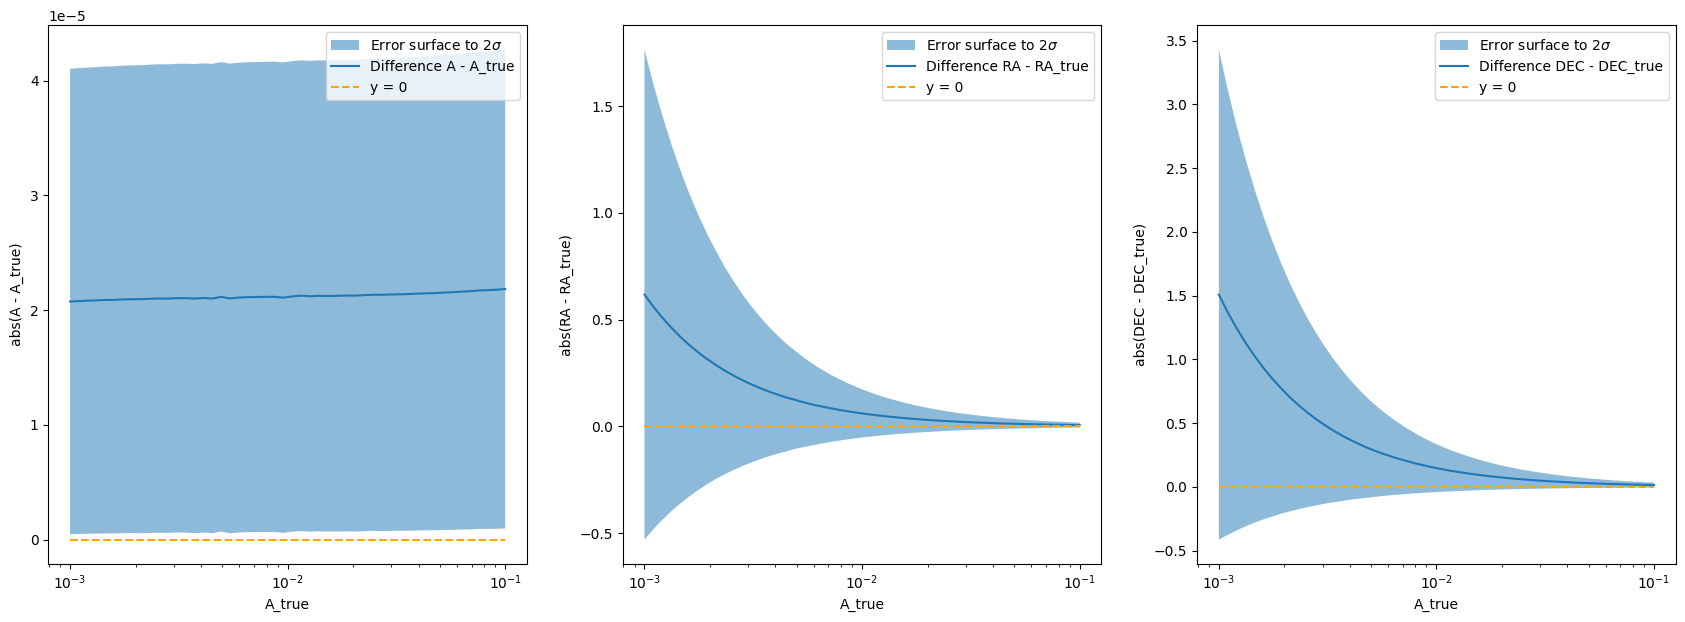

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]))

sufix = f"m5_A_study_diffARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

## Study with clustering

In [37]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_Cluster"
outputfile = DIR + sufix +".fits"

data3 = fitsio.FITS(outputfile)
data3


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [38]:
dfMinuit_data3 = Table(data3['A_STUDY'].read())
mask = dfMinuit_data3["BAND"] == band
dfMinuit_filtered = dfMinuit_data3[mask]
#dfMinuit_filtered = dfMinuit.copy()
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,Cluster_ID,N*_true,A_true,ra_true,dec_true
str3,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,str26,int64,float64,int64,int64
NaN,997987.7859372935,1000000.0,8.831137966713868,False,0.0,inf,0.0018134166658925568,1.0,1.0409664360113e-05,False,0.0,1.0,190.49942571444876,100.0,0.33512697456093576,False,0.0,360.0,23.899884226138013,0.0,0.5150729213731182,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.001,168,-7
NaN,997987.8817424926,1000000.0,8.83146730903536,False,0.0,inf,0.0018925305482702685,1.0,1.0298472591686435e-05,False,0.0,1.0,189.26935514671976,100.0,0.3177499183367729,False,0.0,360.0,22.45437589818181,0.0,0.49565546009126926,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0010985411419875584,168,-7
NaN,997987.8471096883,1000000.0,8.759910687804222,False,0.0,inf,0.001981470536776755,1.0,1.0156586466746574e-05,False,0.0,1.0,188.0575923751327,100.0,0.30043774418220437,False,0.0,360.0,20.979041403883354,0.0,0.4712665641057736,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0012067926406393288,168,-7
NaN,997987.7970290616,1000000.0,8.832339193788357,False,0.0,inf,0.002081308323486997,1.0,1.0099112055763932e-05,False,0.0,1.0,186.87246303383344,100.0,0.2834478123811124,False,0.0,360.0,19.504708144105273,0.0,0.4540833815789327,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0013257113655901094,168,-7
NaN,997987.8580830338,1000000.0,8.832621143432334,False,0.0,inf,0.0021933102707864948,1.0,1.0014314293593785e-05,False,0.0,1.0,185.71596858197,100.0,0.26671169144364626,False,0.0,360.0,18.032447977116757,0.0,0.4322266349295525,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0014563484775012444,168,-7
NaN,997987.7782347717,1000000.0,8.832945489673875,False,0.0,inf,0.0023186252733454335,1.0,9.94011312390841e-06,False,0.0,1.0,184.5956555432784,100.0,0.25038130503362765,False,0.0,360.0,16.57268717806726,0.0,0.4099524798167433,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0015998587196060573,168,-7
NaN,997987.8302784342,1000000.0,8.83343712426722,False,0.0,inf,0.0024587297833345402,1.0,9.877453752984771e-06,False,0.0,1.0,183.5152239628753,100.0,0.23451856405228,False,0.0,360.0,15.13727865122852,0.0,0.387458178238834,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0017575106248547913,168,-7
NaN,997987.8010315656,1000000.0,8.83398735744413,False,0.0,inf,0.002614995717192944,1.0,9.826265204485431e-06,False,0.0,1.0,182.47652516452337,100.0,0.21919711911822048,False,0.0,360.0,13.73447582538192,0.0,0.36496488060628796,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0019306977288832496,168,-7
NaN,997987.7720563979,1000000.0,8.834472093498334,False,0.0,inf,0.002789074350552588,1.0,9.78617456045541e-06,False,0.0,1.0,181.4825991126502,100.0,0.20446320785049465,False,0.0,360.0,12.373121255049089,0.0,0.34266303836516787,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0021209508879201904,168,-7


Saving m5_A_study_diffARaDec_Cluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_diffARaDec_Cluster_band_u.pdf


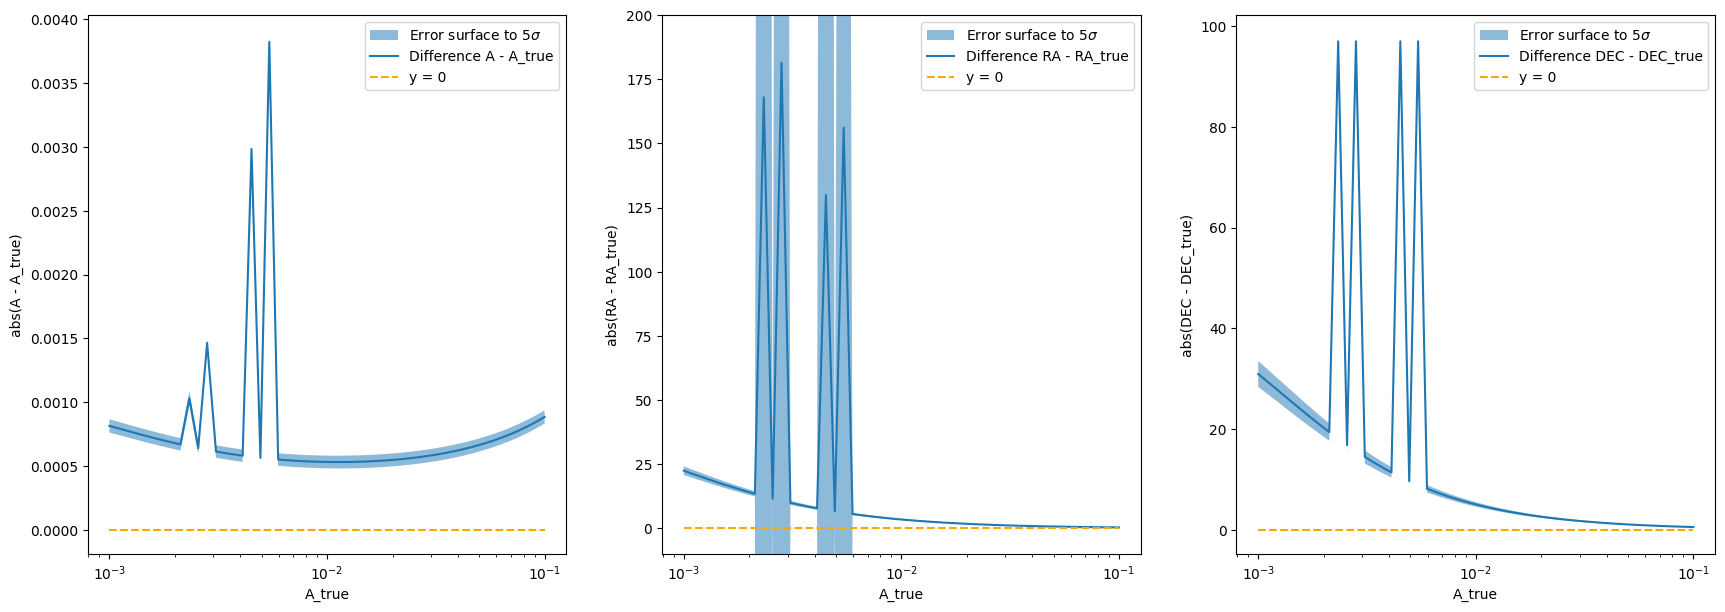

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]))
ax[1].set_ylim([-10, 200])  #used for band u
#ax[1].set_ylim([-10, 130]) #used for band i

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
sufix = f"m5_A_study_diffARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, sufix)